# YOLOE → Any6D Pipeline

**Model-free 6D Pose Estimation using Open-Vocabulary Detection**

---

## Overview

This pipeline combines two state-of-the-art models:

| Model | Role | Input | Output |
|-------|------|-------|--------|
| **YOLOE** | Open-vocabulary detection | Anchor image + Scene image | Bounding box + Segmentation mask |
| **Any6D** | 6D pose estimation | RGB + Depth + Mask | 4×4 Pose matrix |

---

## Pipeline Steps

```
┌─────────────────────────────────────────────────────────────┐
│                    YOLOE → Any6D Pipeline                   │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  Step 1: Load anchor image (reference of the object)        │
│  Step 2: Load scene image (where we want to find object)    │
│  Step 3: Estimate depth with MiDaS (monocular depth)        │
│  Step 4: YOLOE detects object using anchor as visual prompt │
│          → outputs: bbox + segmentation mask                │
│  Step 5: Any6D estimates 6D pose using mask + depth         │
│          → outputs: 4×4 pose matrix (R | t)                 │
│  Step 6: Visualize 3D bounding box on scene image           │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

---

## Requirements

### Environment
- Python 3.10 (`master_env`)
- CUDA GPU (NVIDIA L4 recommended)

### Python packages
```bash
pip install ultralytics timm trimesh opencv-python matplotlib numpy torch
```

### Any6D Docker container
```bash
cd ~/open-vocabulary-6d-pose-yoloe/Any6D
docker compose build
```

### Files needed
```
images/
├── tennis_res.jpg        ← scene image
├── tennis_visual.jpg     ← anchor (reference) image
└── tennis_res_depth.png  ← depth image (generated by MiDaS)

Any6D/demo_data/
└── mustard.obj           ← 3D mesh of the object
```

---

## How to Run

1. Select kernel: `master_env (Python 3.10)`
2. Run all cells in order: `Run All`
3. Results saved to `/tmp/pipeline/`

---
## Cell 1 — Imports & GPU Check

In [42]:
import sys
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import subprocess

# YOLOE
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

print('=' * 60)
print(f'Python:  {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('=' * 60)

Python:  3.10.12
PyTorch: 2.11.0+cu130
CUDA:    True
GPU:     NVIDIA L4
VRAM:    23.7 GB


In [43]:
import sys
sys.path.insert(0, '/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/notebooks')
from helpers import (
    yoloe_text_prompt,
    yoloe_visual_prompt,
    yoloe_free_prompt,
    visualize_detection
)
print('helpers loaded!')

helpers loaded!


---
## Cell 2 — Configuration

**Edit paths here to use your own images.**

In [44]:
# ── Image paths ───────────────────────────────────────────────
BASE_DIR     = '/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe'
ANCHOR_PATH  = f'{BASE_DIR}/images/tennis.jpg'   # reference image of the object
SCENE_PATH   = f'{BASE_DIR}/images/tennis_res.jpg'      # scene to analyze
MESH_PATH    = f'{BASE_DIR}/Any6D/demo_data/mustard.obj' # 3D mesh (replace with your object)

# ── Output paths ──────────────────────────────────────────────
OUTPUT_DIR   = '/tmp/pipeline'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── YOLOE config ──────────────────────────────────────────────
YOLOE_MODEL  = 'yoloe-26l-seg.pt'
CONF_THRESH  = 0.25
model_pf = YOLOE("yoloe-26l-seg-pf.pt")

# ── Depth config ──────────────────────────────────────────────
TARGET_H, TARGET_W = 480, 640   # resize for Any6D (avoids OOM)
DEPTH_MIN_M  = 0.3              # min depth in meters
DEPTH_MAX_M  = 3.0              # max depth in meters

# ── Any6D Docker config ───────────────────────────────────────
ANY6D_DIR    = f'{BASE_DIR}/Any6D'
ITERATIONS   = 5                # pose refinement iterations

print('Configuration:')
print(f'  Anchor:  {ANCHOR_PATH}')
print(f'  Scene:   {SCENE_PATH}')
print(f'  Mesh:    {MESH_PATH}')
print(f'  Output:  {OUTPUT_DIR}')

Configuration:
  Anchor:  /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis.jpg
  Scene:   /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg
  Mesh:    /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/demo_data/mustard.obj
  Output:  /tmp/pipeline


---
## Cell 3 — Step 1 & 2: Load Images

Anchor: (854, 1280, 3)
Scene:  (1707, 1280, 3)


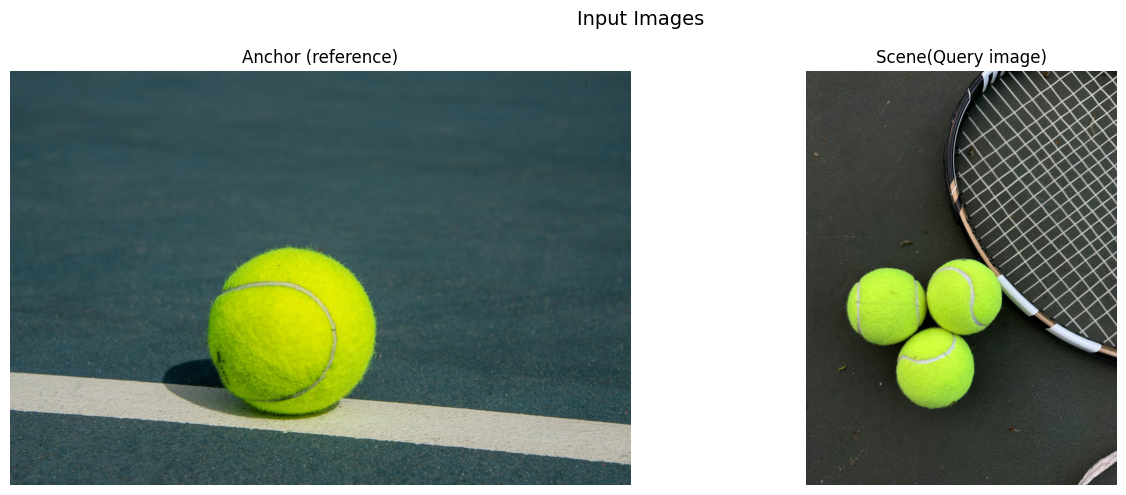

In [45]:
# Load anchor and scene images
anchor_bgr = cv2.imread(ANCHOR_PATH)
scene_bgr  = cv2.imread(SCENE_PATH)
anchor_rgb = cv2.cvtColor(anchor_bgr, cv2.COLOR_BGR2RGB)
scene_rgb  = cv2.cvtColor(scene_bgr,  cv2.COLOR_BGR2RGB)
H, W       = scene_rgb.shape[:2]

print(f'Anchor: {anchor_rgb.shape}')
print(f'Scene:  {scene_rgb.shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(anchor_rgb); axes[0].set_title('Anchor (reference)'); axes[0].axis('off')
axes[1].imshow(scene_rgb);  axes[1].set_title('Scene(Query image)');  axes[1].axis('off')
plt.suptitle('Input Images', fontsize=14)
plt.tight_layout()
plt.show()

---
## Cell 4 — Step 3: Estimate Depth with MiDaS

Step 3: Estimating depth with MiDaS...


Using cache found in /home/josue_aims_ac_za/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /home/josue_aims_ac_za/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /home/josue_aims_ac_za/.cache/torch/hub/intel-isl_MiDaS_master


Depth range: 0.30 - 3.00 m


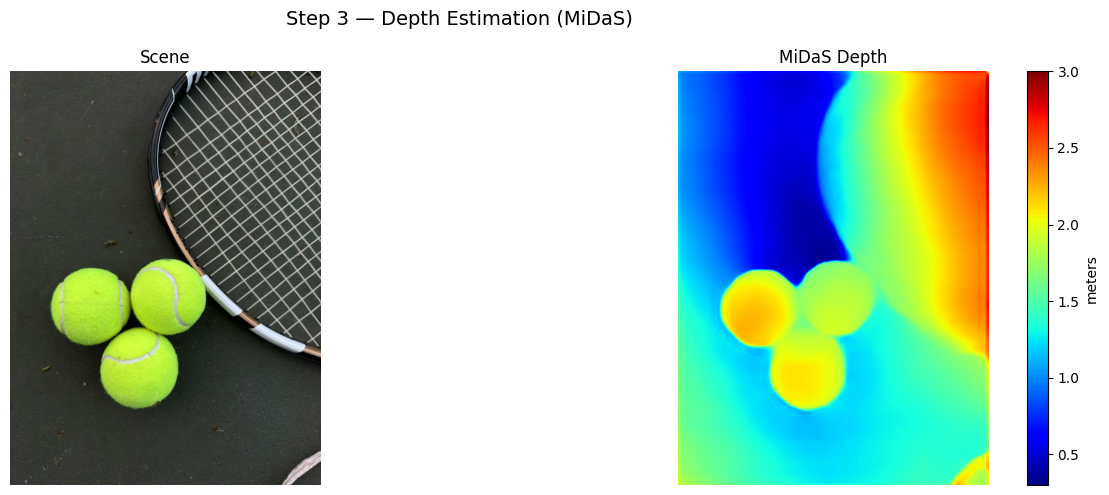

In [46]:
print('Step 3: Estimating depth with MiDaS...')

# Load MiDaS
midas     = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small')
midas.to('cuda').eval()
transform = torch.hub.load('intel-isl/MiDaS', 'transforms').small_transform

# Run MiDaS on scene
input_batch = transform(scene_rgb).to('cuda')
with torch.no_grad():
    depth_pred = midas(input_batch)
    depth_pred = torch.nn.functional.interpolate(
        depth_pred.unsqueeze(1),
        size=(H, W),
        mode='bicubic',
        align_corners=False
    ).squeeze()

depth_map = depth_pred.cpu().numpy()

# Normalize to meters
d_min, d_max = depth_map.min(), depth_map.max()
depth_m = DEPTH_MIN_M + (depth_map - d_min) / (d_max - d_min) * (DEPTH_MAX_M - DEPTH_MIN_M)

print(f'Depth range: {depth_m.min():.2f} - {depth_m.max():.2f} m')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(scene_rgb);                           axes[0].set_title('Scene');         axes[0].axis('off')
im = axes[1].imshow(depth_m, cmap='jet');            axes[1].set_title('MiDaS Depth');   axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='meters')
plt.suptitle('Step 3 — Depth Estimation (MiDaS)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Cell 5 — Step 4: YOLOE Detection with Visual Prompt

In [48]:
import importlib
import helpers
importlib.reload(helpers)
from helpers import (
    yoloe_text_prompt,
    yoloe_visual_prompt,
    yoloe_free_prompt,
    visualize_detection
)
print('helpers reloaded!')

# Vérifier que cv2 est bien dans helpers
import inspect
print(inspect.getsource(helpers).split('\n')[:5])

helpers reloaded!
['import cv2', 'import numpy as np', 'import matplotlib.pyplot as plt', 'from ultralytics import YOLOE', 'from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor']


[Text Prompt] "['ball', 'ball tennis']" → 1 detections
  Best: conf=0.851, bbox=[407 363 754 709]
  Mask: 90904 pixels
Ultralytics 8.4.41 🚀 Python-3.10.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)

image 1/1 /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg: 640x480 3 object0s, 26.2ms
Speed: 2.9ms preprocess, 26.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
[Visual Prompt] anchor_bbox=[407 363 754 709] → 3 detections
  Best: conf=0.559, bbox=[ 165  810  496 1136]
  Mask: 84570 pixels
[Free Prompt] → 6 detections: ['close-up', 'racket', 'trick', 'trick', 'assemble', 'play volleyball']
  Best: conf=0.923, bbox=[   0    0 1280 1698]
  Mask: 1724100 pixels


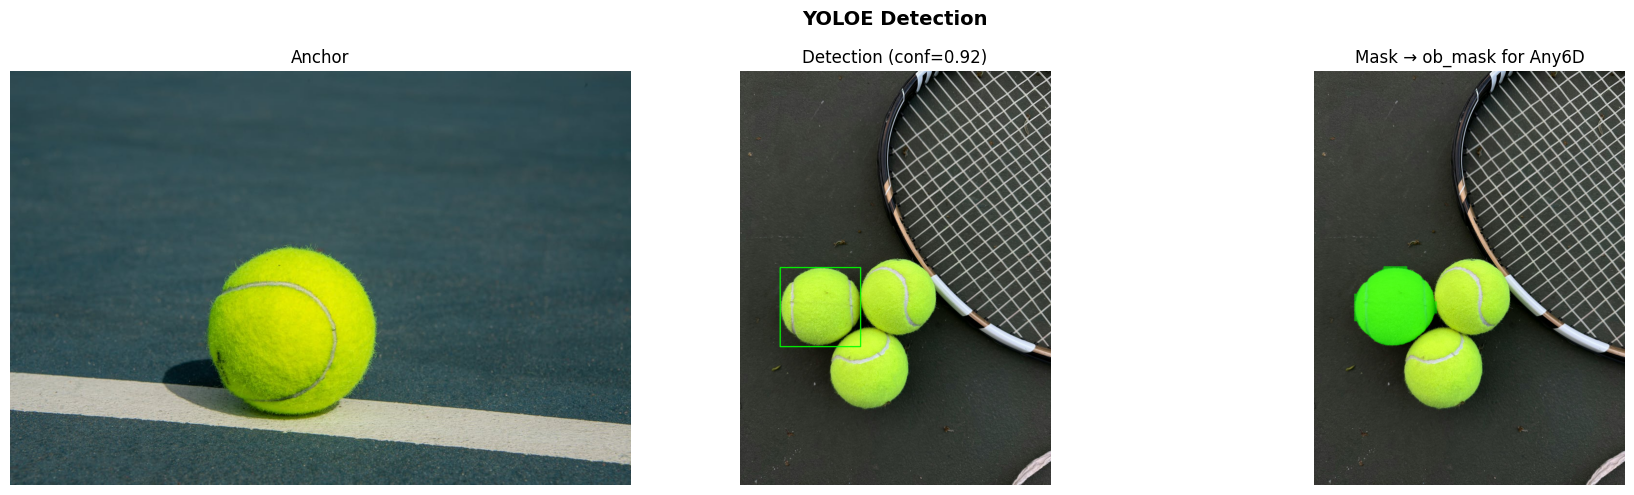

In [49]:
# Text prompt
bbox_xyxy, ob_mask, conf, _ = yoloe_text_prompt(
    model,
    scene_path=ANCHOR_PATH,
    text_prompts=['ball', "ball tennis"]
)

# Visual prompt
bbox_xyxy_visual, ob_mask_visual, conf, _ = yoloe_visual_prompt(
    model,
    scene_path=SCENE_PATH,
    anchor_path=ANCHOR_PATH,
    anchor_bbox=bbox_xyxy
)

# Free prompt
bbox_xyxy_free, ob_mask, conf, _ = yoloe_free_prompt(
    model_pf,
    scene_path=SCENE_PATH
)

# Visualize
visualize_detection(SCENE_PATH, ANCHOR_PATH, bbox_xyxy_visual, ob_mask_visual, conf)

Step 4: Running YOLOE with visual prompt...


Ultralytics 8.4.41 🚀 Python-3.10.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOe-26l-seg summary (fused): 232 layers, 35,437,026 parameters, 2,749,490 gradients, 141.6 GFLOPs

image 1/1 /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg: 640x480 3 object0s, 26.4ms
Speed: 3.0ms preprocess, 26.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Detections found: 3
Best detection: conf=0.559, bbox=[ 165  810  496 1136]
Segmentation mask: 84570 pixels


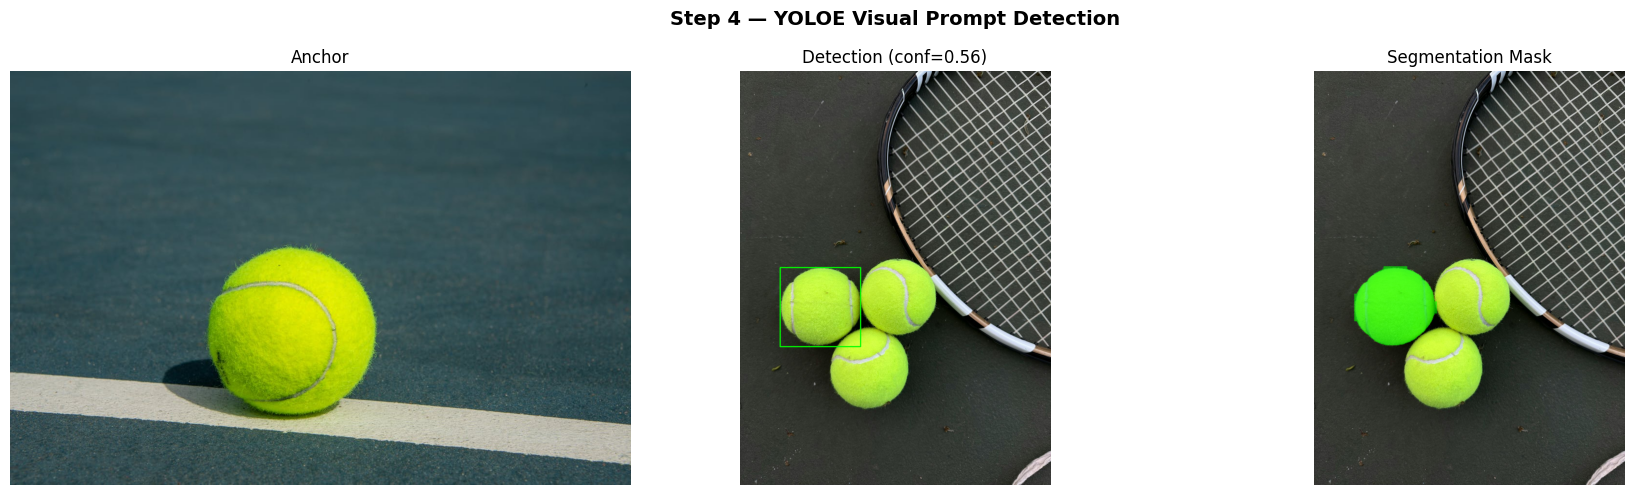

In [53]:
print('Step 4: Running YOLOE with visual prompt...')

# Load YOLOE
model = YOLOE(YOLOE_MODEL)
model.to('cuda')

# Anchor bbox — object location in anchor image
h_a, w_a = anchor_rgb.shape[:2]
# anchor_bbox = bbox_xyxy_visual
anchor_bbox = np.array([bbox_xyxy])
# anchor_bbox = np.array([[0, 0, w_a, h_a]])  # full anchor image [2317, 2084, 4353, 4076]

# Run YOLOE
results = model.predict(
    SCENE_PATH,
    refer_image=ANCHOR_PATH,
    visual_prompts={'cls': [0], 'bboxes':anchor_bbox},
    predictor=YOLOEVPSegPredictor,
    conf=CONF_THRESH
)

result = results[0]
print(f'Detections found: {len(result.boxes)}')

if len(result.boxes) == 0:
    raise ValueError('No object detected! Try adjusting anchor_bbox or conf threshold.')

# Best detection
best_idx  = result.boxes.conf.argmax().item()
bbox_xyxy = result.boxes.xyxy[best_idx].cpu().numpy().astype(int)
conf      = result.boxes.conf[best_idx].item()
print(f'Best detection: conf={conf:.3f}, bbox={bbox_xyxy}')

# Extract segmentation mask
if result.masks is not None:
    raw_mask = result.masks.data[best_idx].cpu().numpy()
    raw_mask = cv2.resize(raw_mask, (W, H))
    ob_mask  = (raw_mask > 0.5).astype(np.bool_)
    print(f'Segmentation mask: {ob_mask.sum()} pixels')
else:
    ob_mask = np.zeros((H, W), dtype=np.bool_)
    x1, y1, x2, y2 = bbox_xyxy
    ob_mask[y1:y2, x1:x2] = True
    print('No segmentation mask — using bbox mask as fallback')

# Visualize
mask_overlay = scene_rgb.copy()
mask_overlay[ob_mask] = (mask_overlay[ob_mask]*0.4 + np.array([0,255,0])*0.6).astype(np.uint8)

scene_bbox = scene_rgb.copy()
x1, y1, x2, y2 = bbox_xyxy
cv2.rectangle(scene_bbox, (x1,y1), (x2,y2), (0,255,0), 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(anchor_rgb);    axes[0].set_title('Anchor');                      axes[0].axis('off')
axes[1].imshow(scene_bbox);    axes[1].set_title(f'Detection (conf={conf:.2f})'); axes[1].axis('off')
axes[2].imshow(mask_overlay);  axes[2].set_title('Segmentation Mask');           axes[2].axis('off')
plt.suptitle('Step 4 — YOLOE Visual Prompt Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 6 — Prepare inputs for Any6D

In [54]:
print('Preparing inputs for Any6D...')

# Resize to 640x480 to avoid CUDA OOM
scene_small = cv2.resize(scene_rgb,         (TARGET_W, TARGET_H))
mask_small  = cv2.resize(ob_mask.astype(np.uint8), (TARGET_W, TARGET_H)) > 0
depth_small = cv2.resize(depth_m,           (TARGET_W, TARGET_H))

# Camera intrinsics (estimated from image size)
scale_x = TARGET_W / W
scale_y = TARGET_H / H
K = np.array([
    [W * scale_x,  0,            W/2 * scale_x],
    [0,            W * scale_y,  H/2 * scale_y],
    [0,            0,            1]
], dtype=np.float64)

# Save to /tmp for Docker container
cv2.imwrite(f'{OUTPUT_DIR}/scene_rgb.png', cv2.cvtColor(scene_small, cv2.COLOR_RGB2BGR))
np.save(f'{OUTPUT_DIR}/ob_mask.npy',  mask_small)
np.save(f'{OUTPUT_DIR}/depth.npy',    depth_small.astype(np.float32))
np.save(f'{OUTPUT_DIR}/K.npy',        K)

# Save depth as 16-bit PNG
depth_mm = (depth_small * 1000).astype(np.uint16)
cv2.imwrite(f'{OUTPUT_DIR}/depth.png', depth_mm)

print(f'Scene resized:  {scene_rgb.shape} → {scene_small.shape}')
print(f'Mask pixels:    {mask_small.sum()}')
print(f'Depth range:    {depth_small.min():.2f} - {depth_small.max():.2f} m')
print(f'All saved to:   {OUTPUT_DIR}/')

Preparing inputs for Any6D...
Scene resized:  (1707, 1280, 3) → (480, 640, 3)
Mask pixels:    11877
Depth range:    0.30 - 3.00 m
All saved to:   /tmp/pipeline/


---
## Cell 7 — Create Any6D script

In [55]:
# Write Any6D script to disk
script = open(f'{OUTPUT_DIR}/run_any6d.py', 'w')
script.write('import sys, os\n')
script.write('import numpy as np\n')
script.write('import cv2\n')
script.write('import trimesh\n')
script.write('sys.path.insert(0, "/workspace")\n')
script.write('sys.path.insert(0, "/workspace/foundationpose/mycpp/build")\n')
script.write('import nvdiffrast.torch as dr\n')
script.write('from estimater import Any6D\n')
script.write('from pytorch_lightning import seed_everything\n')
script.write('seed_everything(0)\n')
script.write('glctx = dr.RasterizeCudaContext()\n')
script.write('ob_mask   = np.load("/tmp/pipeline/ob_mask.npy")\n')
script.write('scene_bgr = cv2.imread("/tmp/pipeline/scene_rgb.png")\n')
script.write('scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)\n')
script.write('depth     = np.load("/tmp/pipeline/depth.npy")\n')
script.write('K         = np.load("/tmp/pipeline/K.npy")\n')
script.write('print("ob_mask:", ob_mask.sum(), "pixels")\n')
script.write('print("scene:", scene_rgb.shape)\n')
script.write('print("depth:", depth.min().round(2), "-", depth.max().round(2), "m")\n')
script.write('mesh = trimesh.load("/workspace/demo_data/mustard.obj")\n')
script.write('os.makedirs("/tmp/pipeline/results", exist_ok=True)\n')
script.write('est = Any6D(symmetry_tfs=None, mesh=mesh, debug_dir="/tmp/pipeline/results", debug=0)\n')
script.write('pred_pose = est.register_any6d(K=K, rgb=scene_rgb, depth=depth, ob_mask=ob_mask, iteration=5, name="yoloe_any6d")\n')
script.write('np.save("/tmp/pipeline/pose.npy", pred_pose)\n')
script.write('np.savetxt("/tmp/pipeline/pose.txt", pred_pose)\n')
script.write('t = pred_pose[:3, 3]\n')
script.write('print("POSE RESULT:")\n')
script.write('print(pred_pose)\n')
script.write('print("X:", round(float(t[0])*100,1), "cm")\n')
script.write('print("Y:", round(float(t[1])*100,1), "cm")\n')
script.write('print("Z:", round(float(t[2])*100,1), "cm")\n')
script.close()
print(f'Script saved to {OUTPUT_DIR}/run_any6d.py')

Script saved to /tmp/pipeline/run_any6d.py


---
## Cell 8 — Step 5: Run Any6D in Docker

In [ ]:
print('Step 5: Running Any6D inside Docker container...')
print('This may take 1-2 minutes...')

# Remplacez cmd par :
cmd = [
    'docker', 'compose', 'run', '--rm',
    '--entrypoint', '',
    '-v', '/tmp/pipeline:/tmp/pipeline',
    'any6d',
    '/bin/bash', '--login', '-c',
    'python /tmp/pipeline/run_any6d.py'
]

proc = subprocess.run(
    cmd,
    cwd=ANY6D_DIR,
    capture_output=True,
    text=True,
    timeout=300
)

print(proc.stdout)
if proc.returncode != 0:
    print('STDERR:', proc.stderr[-2000:])
else:
    print('Any6D completed successfully!')

Step 5: Running Any6D inside Docker container...
This may take 1-2 minutes...


---
## Cell 9 — Step 6: Visualize 6D Pose Result

In [ ]:
import trimesh

# Load pose result
pred_pose = np.load(f'{OUTPUT_DIR}/pose.npy')
K_small   = np.load(f'{OUTPUT_DIR}/K.npy')
mesh      = trimesh.load(MESH_PATH)

t = pred_pose[:3, 3]
R = pred_pose[:3, :3]

print('=== 6D POSE RESULT ===')
print(pred_pose)
print(f'\nObject position:')
print(f'  X = {t[0]*100:.1f} cm')
print(f'  Y = {t[1]*100:.1f} cm')
print(f'  Z = {t[2]*100:.1f} cm (depth)')

# Project 3D bbox onto image
def project_bbox_3d(mesh, pose, K):
    b = mesh.bounds
    corners = np.array([
        [b[0,0],b[0,1],b[0,2]], [b[1,0],b[0,1],b[0,2]],
        [b[1,0],b[1,1],b[0,2]], [b[0,0],b[1,1],b[0,2]],
        [b[0,0],b[0,1],b[1,2]], [b[1,0],b[0,1],b[1,2]],
        [b[1,0],b[1,1],b[1,2]], [b[0,0],b[1,1],b[1,2]]
    ])
    pts_cam = (pose[:3,:3] @ corners.T + pose[:3,3:]).T
    pts_2d  = (K @ pts_cam.T).T
    return (pts_2d[:,:2] / pts_2d[:,2:]).astype(int)

def draw_bbox_3d(img, pts, color=(0,255,0), thickness=2):
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    img = img.copy()
    for i, j in edges:
        cv2.line(img, tuple(pts[i]), tuple(pts[j]), color, thickness)
    return img

# Final visualization
scene_small = cv2.resize(scene_rgb, (TARGET_W, TARGET_H))
mask_small  = cv2.resize(ob_mask.astype(np.uint8), (TARGET_W, TARGET_H)) > 0
mask_vis    = scene_small.copy()
mask_vis[mask_small] = (mask_vis[mask_small]*0.4 + np.array([0,255,0])*0.6).astype(np.uint8)

try:
    pts      = project_bbox_3d(mesh, pred_pose, K_small)
    pose_img = draw_bbox_3d(scene_small, pts, color=(0,255,0), thickness=3)
    pose_ok  = True
except Exception as e:
    pose_img = scene_small.copy()
    pose_ok  = False
    print(f'Visualization error: {e}')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(anchor_rgb);  axes[0].set_title('Anchor (reference)');              axes[0].axis('off')
axes[1].imshow(mask_vis);    axes[1].set_title(f'YOLOE Mask (conf={conf:.2f})');   axes[1].axis('off')
axes[2].imshow(pose_img);    axes[2].set_title('Any6D 6D Pose (green bbox)');      axes[2].axis('off')

plt.suptitle('YOLOE → Any6D Pipeline Result', fontsize=16, fontweight='bold')
plt.tight_layout()

out_path = f'{OUTPUT_DIR}/pipeline_result.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Result saved: {out_path}')